# Unsupervised Learning Demo

Clustering, dimensionality reduction, and density estimation from scratch.

In [1]:
import sys
import os

# Menambahkan folder utama ke daftar pencarian Python
sys.path.append(os.path.abspath("..")) 

import mlengine as mle
print(mle.__version__)

0.1.0


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, load_digits
import mlengine as mle

## K-Means++ vs Random Init

kmeans++    : mean inertia = 879.3 ± 275.1
random      : mean inertia = 1393.0 ± 997.1


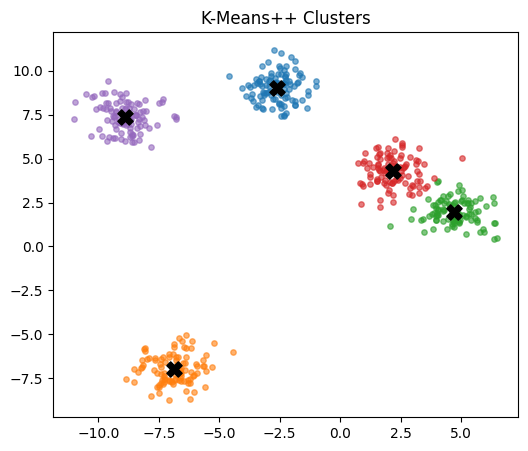

In [3]:
X, y_true = make_blobs(n_samples=500, centers=5, cluster_std=0.8, random_state=42)

for init in ['kmeans++', 'random']:
    inertias = [mle.KMeans(n_clusters=5, init=init, n_init=1, random_state=i).fit(X).inertia_
                for i in range(10)]
    print(f'{init:12s}: mean inertia = {np.mean(inertias):.1f} ± {np.std(inertias):.1f}')

km = mle.KMeans(n_clusters=5, random_state=42).fit(X)
plt.figure(figsize=(6,5))
for k in range(5):
    plt.scatter(X[km.labels_==k, 0], X[km.labels_==k, 1], s=15, alpha=0.6)
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], c='k', marker='X', s=120)
plt.title('K-Means++ Clusters'); plt.show()

## DBSCAN on Non-Convex Data

Clusters found: 2  |  Noise points: 0


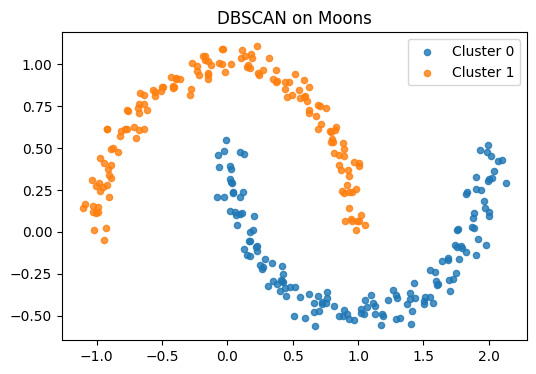

In [4]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)
db = mle.DBSCAN(eps=0.2, min_samples=5).fit(X_moons)
print(f'Clusters found: {db.n_clusters_}  |  Noise points: {(db.labels_==-1).sum()}')

plt.figure(figsize=(6,4))
for lab in np.unique(db.labels_):
    mask = db.labels_ == lab
    label = 'Noise' if lab == -1 else f'Cluster {lab}'
    plt.scatter(X_moons[mask,0], X_moons[mask,1], s=20, label=label, alpha=0.8)
plt.legend(); plt.title('DBSCAN on Moons'); plt.show()

## PCA + Explained Variance

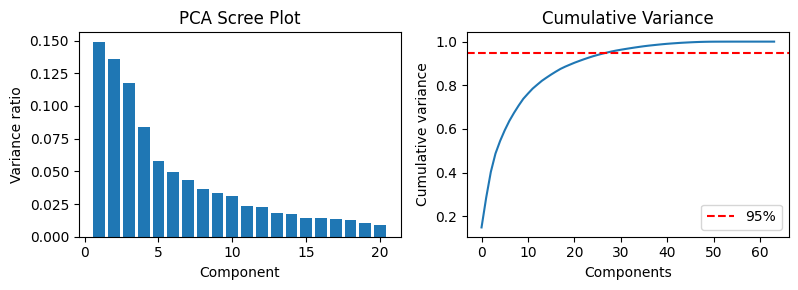

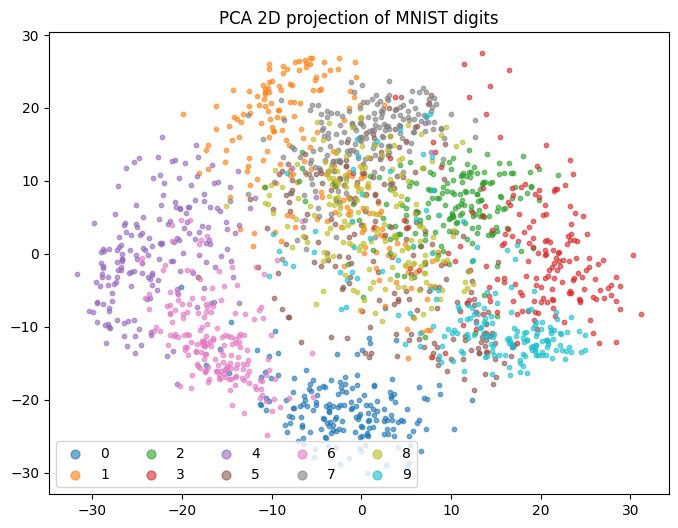

In [5]:
digits = load_digits()
X_d, y_d = digits.data, digits.target

pca = mle.PCA().fit(X_d)
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.bar(range(1, 21), pca.explained_variance_ratio_[:20])
plt.xlabel('Component'); plt.ylabel('Variance ratio'); plt.title('PCA Scree Plot')

plt.subplot(1,2,2)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(0.95, c='r', ls='--', label='95%')
plt.xlabel('Components'); plt.ylabel('Cumulative variance'); plt.title('Cumulative Variance')
plt.legend(); plt.tight_layout(); plt.show()

X_2d = mle.PCA(n_components=2).fit_transform(X_d)
plt.figure(figsize=(8,6))
for digit in range(10):
    mask = y_d == digit
    plt.scatter(X_2d[mask,0], X_2d[mask,1], s=10, label=str(digit), alpha=0.6)
plt.legend(ncol=5, markerscale=2); plt.title('PCA 2D projection of MNIST digits'); plt.show()

## Gaussian Mixture Model

GMM log-likelihood: -1160.57
Component weights: [0.333 0.333 0.333]


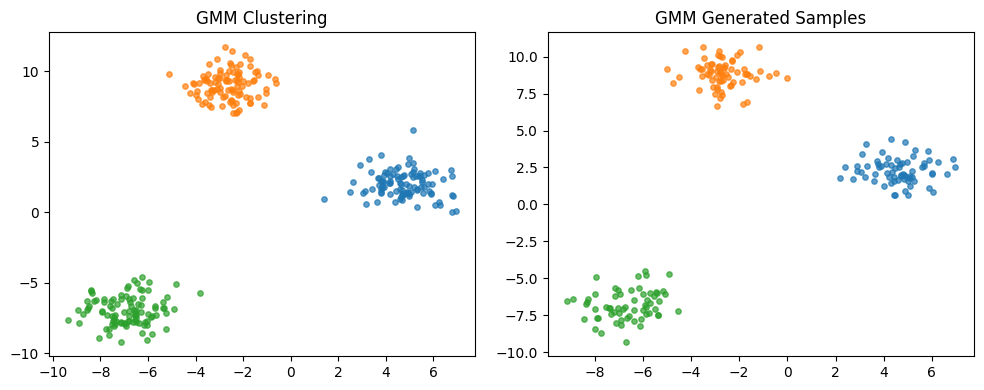

In [6]:
X_blobs, _ = make_blobs(n_samples=300, centers=3, random_state=42)
gmm = mle.GaussianMixture(n_components=3, random_state=42, n_init=3).fit(X_blobs)
print(f'GMM log-likelihood: {gmm.lower_bound_:.2f}')
print(f'Component weights: {gmm.weights_.round(3)}')

X_gen, labels_gen = gmm.sample(200)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
preds = gmm.predict(X_blobs)
for k in range(3):
    plt.scatter(X_blobs[preds==k,0], X_blobs[preds==k,1], s=15, alpha=0.7)
plt.title('GMM Clustering')
plt.subplot(1,2,2)
for k in range(3):
    plt.scatter(X_gen[labels_gen==k,0], X_gen[labels_gen==k,1], s=15, alpha=0.7)
plt.title('GMM Generated Samples')
plt.tight_layout(); plt.show()